In [ ]:
#K-Means Clustering
#Finding Optimal Number of Components — Elbow Method

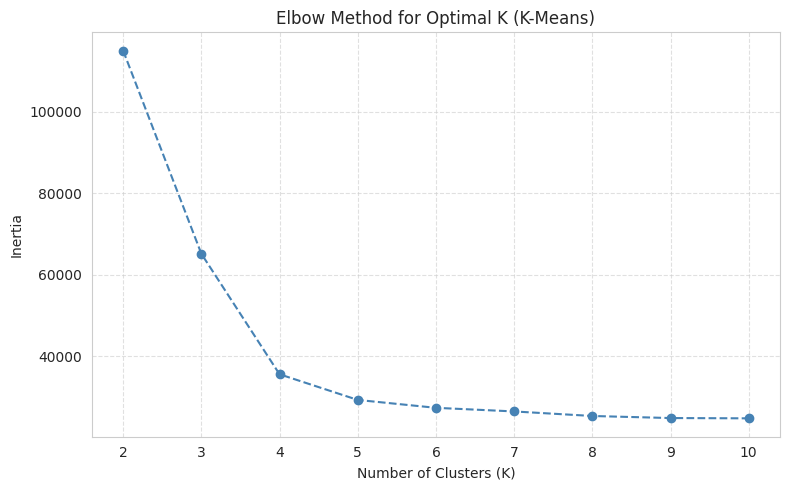

Interpretation: Look for the 'elbow' point where the decrease in inertia starts to level off. This suggests an optimal K.


In [ ]:
from sklearn.cluster import KMeans

inertia_values = []
n_range = range(2, 11)

for n in n_range:
    kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_array)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(n_range, inertia_values, marker='o', linestyle='--', color='steelblue')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K (K-Means)')
plt.xticks(n_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Based on the plot, identify the 'elbow' point
# (Often where the rate of decrease in inertia significantly slows down)
# For demonstration, let's pick a plausible elbow point (e.g., K=4 or K=5 from typical results)
# User would interpret this visually. For now, I'll print a note.
print("Interpretation: Look for the 'elbow' point where the decrease in inertia starts to level off. This suggests an optimal K.")

In [ ]:
##Finding Optimal Number of Components — Silhouette Score

K= 2 | Silhouette: 0.4348
K= 3 | Silhouette: 0.5621
K= 4 | Silhouette: 0.6292
K= 5 | Silhouette: 0.6463
K= 6 | Silhouette: 0.5770
K= 7 | Silhouette: 0.5151
K= 8 | Silhouette: 0.5203
K= 9 | Silhouette: 0.5196
K=10 | Silhouette: 0.2685

 Best K by Silhouette for K-Means: 5


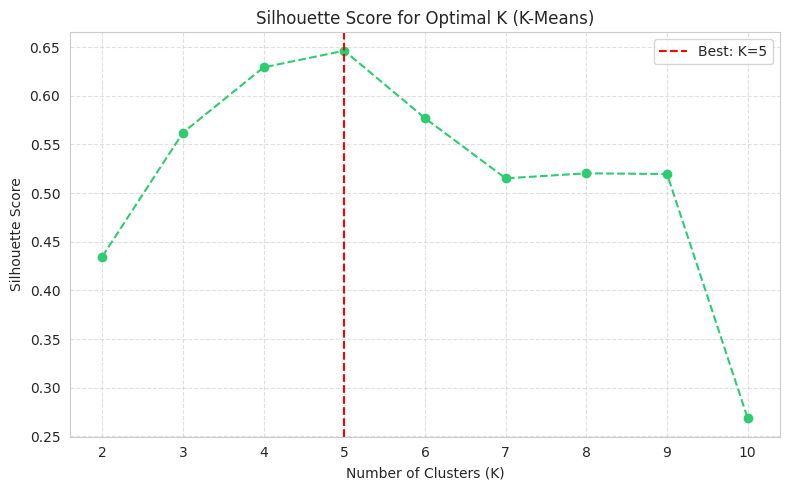

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores_kmeans = []
n_range = range(2, 11) # Same range as for Elbow method

for n in n_range:
    kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_array)
    labels_kmeans = kmeans.predict(scaled_array)
    sil_kmeans = silhouette_score(scaled_array, labels_kmeans, sample_size=3000, random_state=42)
    silhouette_scores_kmeans.append(sil_kmeans)
    print(f"K={n:2d} | Silhouette: {sil_kmeans:.4f}")

optimal_n_kmeans_sil = list(n_range)[np.argmax(silhouette_scores_kmeans)]
print(f"\n Best K by Silhouette for K-Means: {optimal_n_kmeans_sil}")

plt.figure(figsize=(8, 5))
plt.plot(n_range, silhouette_scores_kmeans, marker='o', linestyle='--', color='#2ecc71')
plt.axvline(optimal_n_kmeans_sil, color='red', linestyle='--', label=f'Best: K={optimal_n_kmeans_sil}')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal K (K-Means)')
plt.xticks(n_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
kmeans_std_final = KMeans(n_clusters=optimal_n_kmeans_sil, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_std_final.fit(scaled_array)
labels_kmeans_std = kmeans_std_final.predict(scaled_array)

print(f"Standard K-Means clustering completed with {optimal_n_kmeans_sil} clusters.")

Standard K-Means clustering completed with 5 clusters.


In [ ]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score

# Calculate metrics for Standard K-Means
sil_kmeans_std = silhouette_score(scaled_array, labels_kmeans_std, sample_size=3000, random_state=42)
db_score_kmeans_std = davies_bouldin_score(scaled_array, labels_kmeans_std)
ch_score_kmeans_std = calinski_harabasz_score(scaled_array, labels_kmeans_std)

print(f"\nK-Means Standard Metrics (K={optimal_n_kmeans_sil}):")
print(f"  Silhouette Score: {sil_kmeans_std:.4f}")
print(f"  Davies-Bouldin Index: {db_score_kmeans_std:.4f}")
print(f"  Calinski-Harabasz Index: {ch_score_kmeans_std:.4f}")


K-Means Standard Metrics (K=5):
  Silhouette Score: 0.6463
  Davies-Bouldin Index: 1.0058
  Calinski-Harabasz Index: 16742.3582


In [ ]:
# Calculate overall means for business interpretation reference
key_features_for_overall_mean = [
    'BALANCE','PURCHASES','CASH_ADVANCE','PAYMENTS',
    'CREDIT_LIMIT','PRC_FULL_PAYMENT','PURCHASES_FREQUENCY'
]
# Use the original df which has the log-transformed values that the profiling also uses.
overall_means = df[key_features_for_overall_mean].mean()
print("Overall means for business interpretation (using preprocessed df):")
display(overall_means)

Overall means for business interpretation (using preprocessed df):


,0
BALANCE,2179.30
PURCHASES,3099.50
CASH_ADVANCE,1313.09
PAYMENTS,2252.19
CREDIT_LIMIT,5034.62
PRC_FULL_PAYMENT,0.16
PURCHASES_FREQUENCY,0.46


In [ ]:

#Evaluation & Visualization (Standard K-Means)

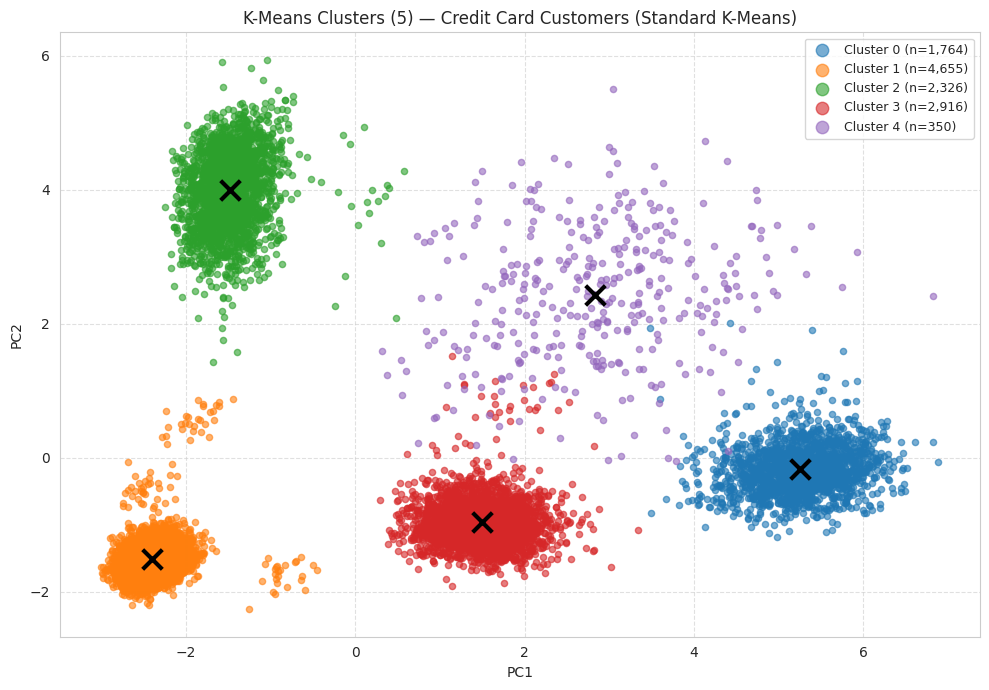

In [ ]:
# Visualize the clusters using PCA on the scaled data for 2D plotting
colors_kmeans_std = [f'C{i}' for i in range(optimal_n_kmeans_sil)]

plt.figure(figsize=(10, 7))

# Project the 17D centroids down to 2D PCA space for plotting
centroids_pca = pca.transform(kmeans_std_final.cluster_centers_)

for k in range(optimal_n_kmeans_sil):
    mask = labels_kmeans_std == k
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors_kmeans_std[k],
                alpha=0.6, s=20, label=f'Cluster {k} (n={mask.sum():,})')
    # Plot the projected centroids
    plt.scatter(centroids_pca[k, 0], centroids_pca[k, 1],
                c='black', marker='x', s=200, linewidths=3, zorder=5) # Black 'x' for centroid
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(markerscale=2, fontsize=9)
plt.title(f'K-Means Clusters ({optimal_n_kmeans_sil}) — Credit Card Customers (Standard K-Means)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()

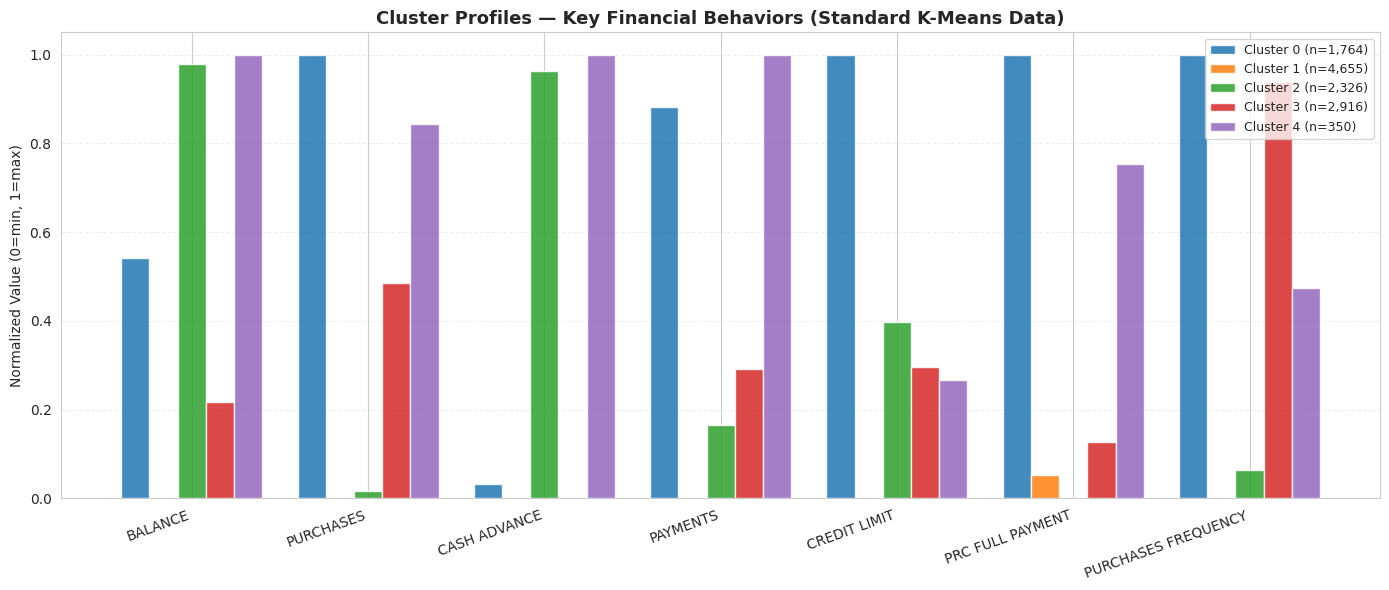

In [ ]:
# Add cluster labels to the original dataframe for profiling
df_result_kmeans_std = df.copy()
df_result_kmeans_std['Cluster_Standard_KMeans'] = labels_kmeans_std

profile_plot_kmeans_std = df_result_kmeans_std.groupby('Cluster_Standard_KMeans')[key_features_for_overall_mean].mean()

# Normalize for visualization
profile_norm_kmeans_std = (profile_plot_kmeans_std - profile_plot_kmeans_std.min()) / (profile_plot_kmeans_std.max() - profile_plot_kmeans_std.min())

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(key_features_for_overall_mean))
width = 0.8 / optimal_n_kmeans_sil

colors_kmeans_std_plot = [f'C{i}' for i in range(optimal_n_kmeans_sil)]

for k in range(optimal_n_kmeans_sil):
    ax.bar(x + k*width, profile_norm_kmeans_std.iloc[k], width,
           label=f'Cluster {k} (n={(labels_kmeans_std==k).sum():,})',
           color=colors_kmeans_std_plot[k], alpha=0.85)

ax.set_xticks(x + width*(optimal_n_kmeans_sil-1)/2)
ax.set_xticklabels([f.replace('_',' ') for f in key_features_for_overall_mean], rotation=20, ha='right')
ax.set_ylabel('Normalized Value (0=min, 1=max)')
ax.set_title('Cluster Profiles — Key Financial Behaviors (Standard K-Means Data)', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout(); plt.show()

/tmp/ipykernel_5902/636103057.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Standard_KMeans', y=feature, data=df_result_kmeans_std, ax=axes[i], palette='viridis')
/tmp/ipykernel_5902/636103057.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Standard_KMeans', y=feature, data=df_result_kmeans_std, ax=axes[i], palette='viridis')
/tmp/ipykernel_5902/636103057.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Standard_KMeans', y=feature, data=df_result_kmeans_std, ax=axes[i], palette='viridis')
/tmp

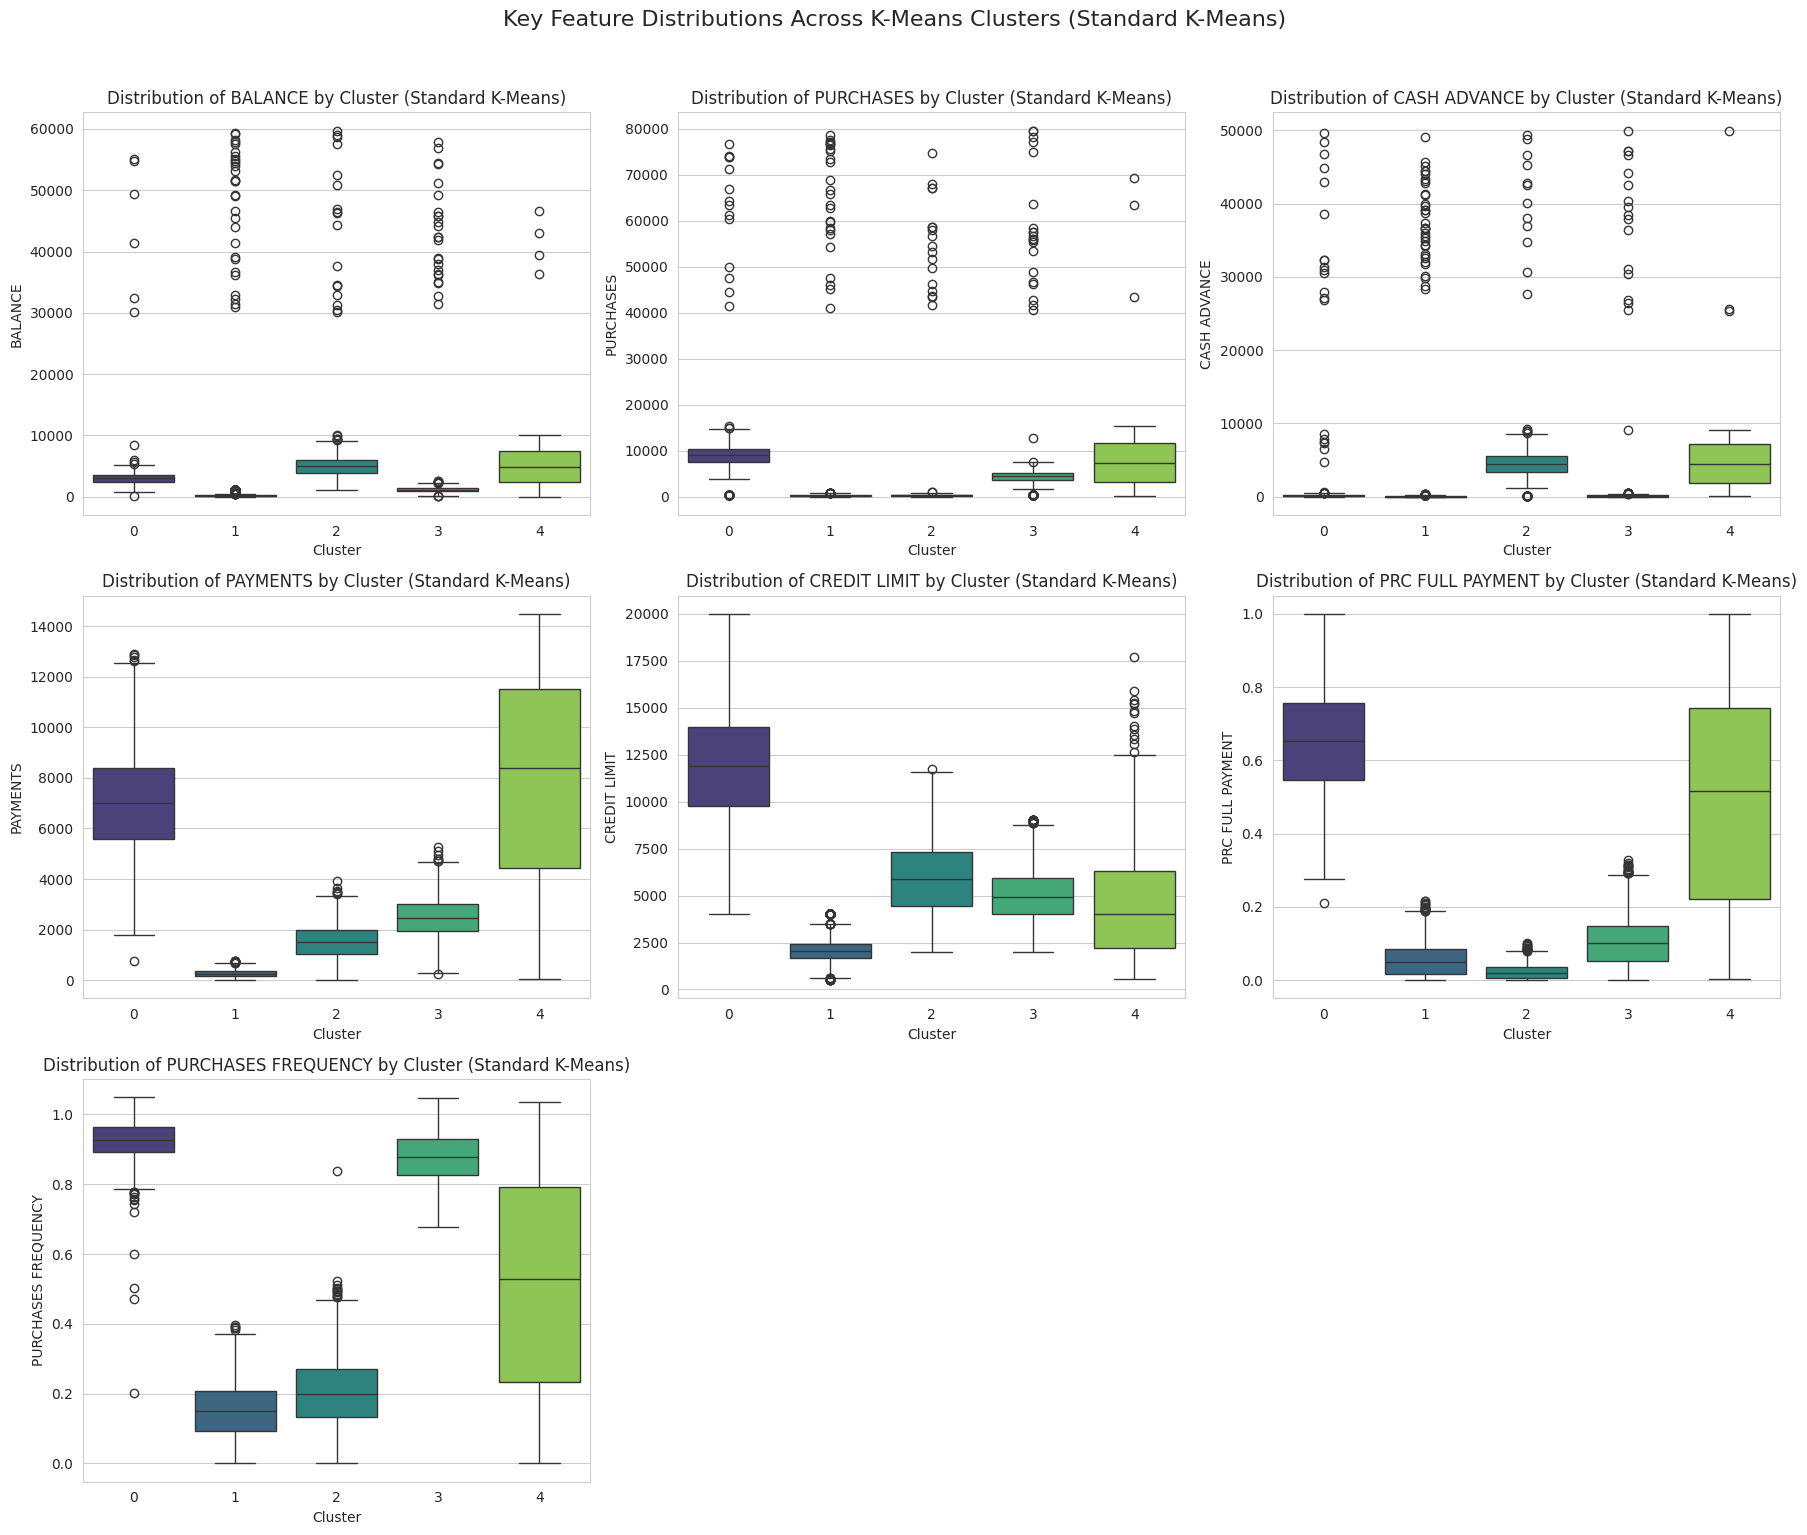

In [ ]:
import seaborn as sns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 15))
axes = axes.flatten()

selected_features = [
    'BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS',
    'CREDIT_LIMIT', 'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY'
]

# Use df_result_kmeans_std and Cluster_Standard_KMeans for standard K-Means profiling
for i, feature in enumerate(selected_features):
    if i < len(axes):
        sns.boxplot(x='Cluster_Standard_KMeans', y=feature, data=df_result_kmeans_std, ax=axes[i], palette='viridis')
        axes[i].set_title(f'Distribution of {feature.replace("_", " ")} by Cluster (Standard K-Means)')
        axes[i].set_xlabel('Cluster')
        axes[i].set_ylabel(feature.replace("_", " "))

# Remove any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Key Feature Distributions Across K-Means Clusters (Standard K-Means)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#Consolidated Evaluation Metrics Comparison

In [ ]:
results_comparison = pd.DataFrame({
    'method': [
        'K-Means (Standard)'

    ],
    'Optimal K': [
        optimal_n_kmeans_sil

    ],
    'Silhouette': [
        sil_kmeans_std

    ],
    'Davies-Bouldin': [
        db_score_kmeans_std

    ],
    'Calinski-Harabasz': [
        ch_score_kmeans_std

    ]
})

print('\n=== Comprehensive Clustering Metrics Comparison ===')
print(results_comparison.to_string(index=False))

print('\n**Interpretation Guidelines:**')
print('- **Silhouette Score**: Higher is better (range -1 to 1). Indicates how well-separated clusters are.')
print('- **Davies-Bouldin Index**: Lower is better. Measures the average similarity ratio of each cluster with its most similar cluster. Lower values indicate better partitioning.')
print('- **Calinski-Harabasz Index**: Higher is better. Measures the ratio of the sum of between-clusters dispersion to within-cluster dispersion.')


=== Comprehensive Clustering Metrics Comparison ===
            method  Optimal K  Silhouette  Davies-Bouldin  Calinski-Harabasz
K-Means (Standard)          5        0.65            1.01           16742.36

**Interpretation Guidelines:**
- **Silhouette Score**: Higher is better (range -1 to 1). Indicates how well-separated clusters are.
- **Davies-Bouldin Index**: Lower is better. Measures the average similarity ratio of each cluster with its most similar cluster. Lower values indicate better partitioning.
- **Calinski-Harabasz Index**: Higher is better. Measures the ratio of the sum of between-clusters dispersion to within-cluster dispersion.


In [ ]:
import joblib

# Define paths for saving
kmeans_model_path = 'kmeans_best_model.joblib'
standard_scaler_path = 'standard_scaler.joblib'
best_model_type_path = 'best_kmeans_model_type.joblib'

# Save the Standard K-Means model components
joblib.dump(kmeans_std_final, kmeans_model_path)
joblib.dump(scaler, standard_scaler_path)
joblib.dump('standard_kmeans', best_model_type_path)

print(f" K-Means model (Standard K-Means) with {optimal_n_kmeans_sil} clusters saved to: {kmeans_model_path}")
print(f"StandardScaler saved to: {standard_scaler_path}")
print(f"Best model type saved to: {best_model_type_path}")

print(f"All selected models and assets saved successfully.")

 K-Means model (Standard K-Means) with 5 clusters saved to: kmeans_best_model.joblib
StandardScaler saved to: standard_scaler.joblib
Best model type saved to: best_kmeans_model_type.joblib
All selected models and assets saved successfully.


### How to Load and Use the Saved Models

To use the saved models for new data, you'll need to load the `StandardScaler` and the `kmeans_best_model.joblib`. If the best model happened to be the Autoencoder-based K-Means, you would also need to load the `pytorch_autoencoder_model.joblib` to process new data into latent features before clustering.

Here's how you can load and use these models: